# 00 — Build Unified EO Datastack

*La Palma 2021 multi-sensor harmonization for an analysis-ready Earth Observation datastack.*

This notebook consolidates preprocessed Sentinel-1, Sentinel-2, terrain, land-cover, and lava-reference inputs, and derives the validity and analysis-domain masks required by the downstream workflow.

This notebook is a consolidation step. It assumes that the sensor-specific preprocessing has already been completed and focuses on harmonizing the resulting inputs into a single analysis-ready raster stack.

It is not a raw-product downloader, a complete Copernicus Browser or Google Earth Engine acquisition pipeline, a complete SNAP preprocessing pipeline, or the final analytical notebook. The downstream analysis is handled separately in `notebooks/01_lapalma_analysis_final.ipynb`.


## Notebook Scope and Provenance

The Sentinel-1 and Sentinel-2 inputs used here are already preprocessed. Upstream acquisition and preprocessing were carried out through the broader AI4EO laboratory workflow, including Copernicus Browser, Google Earth Engine, SNAP preprocessing, NetCDF export, and Colab-based processing. Those upstream stages are part of the project provenance, but they are not fully reproduced by this repository.

This repository starts reproducibility primarily from the preprocessed-input and harmonization stage. Large raster and NetCDF files are excluded from Git and must be placed locally before rebuilding or validating the datastack. Local input placement is documented in `data/README.md`, while upstream acquisition and preprocessing provenance is documented in `docs/DATA_PIPELINE.md`.

The output of this notebook is the analysis-ready foundation used by `notebooks/01_lapalma_analysis_final.ipynb`.


## Repository Workflow

```text
Preprocessed EO and auxiliary inputs
↓
notebooks/00_build_unified_datastack.ipynb
↓
204-band unified EO datastack and metadata table
↓
notebooks/01_lapalma_analysis_final.ipynb
↓
Change diagnostics, RF spectral evidence, constrained timing reconstruction, and exposure assessment
```


## Required Inputs

The paths below are repository-relative. Validity masks are not listed as external inputs because they are generated inside this notebook from the harmonized layers.

| Input | Path(s) | Expected content | Role |
|---|---|---|---|
| Sentinel-2 temporal stack | `data/processed/s2_stack/S2_LaPalma_stack_EPSG32628_10m.nc` | 23 eruption-period dates, six reflectance bands, coordinates, timestamps, and spatial reference | Reference grid and optical progression |
| Additional Sentinel-2 pre/post files | `data/processed/s2_extra/S2_20210826.nc`; `data/processed/s2_extra/S2_20220103.nc` | 2021-08-26 and 2022-01-03, B2/B3/B4/B8/B11/B12 | Before/after comparison |
| Sentinel-1 files | `data/processed/s1/S1_20210823.nc`; `data/processed/s1/S1_20210928.nc`; `data/processed/s1/S1_20211022.nc`; `data/processed/s1/S1_20211203.nc`; `data/processed/s1/S1_20220108.nc` | Five VV/VH acquisitions with usable georeferencing | Cloud-independent SAR support |
| DEM raster | `data/auxiliary/DEM.tif` | Four bands: 1 elevation, 2 slope, 3 aspect, 4 hillshade | Terrain context |
| ESA WorldCover | `data/auxiliary/ESA_WorldCover.tif` | Land-cover class codes | Exposure assessment |
| Auxiliary lava NetCDF | `data/auxiliary/auxiliary_data.nc` | Lava extent and coordinate information | Final affected-domain reference |


## Datastack Composition

The expected unified datastack contains exactly 204 bands:

| Component | Count |
|---|---:|
| Sentinel-2 reflectance bands | 150 |
| Sentinel-1 VV/VH dB bands | 10 |
| Static layers | 6 |
| Sentinel-2 validity masks | 25 |
| Sentinel-1 validity masks | 5 |
| Static/domain masks | 5 |
| Pre/post comparison masks | 3 |
| **Total** | **204** |

The static layers are `land_cover`, `lava_reference`, `elevation`, `slope_degrees`, `aspect_degrees`, and `hillshade`. Derived analytical products are deliberately excluded from the datastack. This includes NDVI, NBR, NDMI, BSI, temporal differences, heat index, SWIR slope, SAR ratios and log-ratios, change scores, Random Forest predictions, classified maps, arrival-day maps, impact maps, latitude bands, longitude bands, and temporal descriptor bands.


## What This Notebook Does Not Do

This notebook does not download raw Sentinel products, reproduce the complete SNAP workflow, perform atmospheric correction, perform the final downstream scientific analyses, create final RF classifications, create arrival-time maps, create impact summaries, add derived analytical products to the datastack, or include OSM vector data as GeoTIFF bands.

For downstream interpretation, change diagnostics, Random Forest spectral-evidence classification, constrained timing reconstruction, and exposure assessment, use `notebooks/01_lapalma_analysis_final.ipynb`.


## Setup and Repository-Relative Paths

Canonical outputs are the validated project artifacts consumed by downstream analysis. This notebook validates those files read-only by default.

Candidate outputs are optional rebuild products written to separate `_candidate` filenames. Promotion from candidate to canonical is deliberately outside this public notebook; any candidate must pass validation before manual replacement of canonical files.


In [1]:
from pathlib import Path
from io import BytesIO
import numpy as np
import pandas as pd
import rasterio
import xarray as xr
from IPython.display import display, Image as IPyImage
from PIL import Image as PILImage, ImageDraw
from rasterio.crs import CRS
from rasterio.enums import Resampling
from rasterio.transform import Affine
from rasterio.warp import reproject

BUILD_CANDIDATE_OUTPUTS = False
OVERWRITE_CANDIDATE_OUTPUTS = False
WRITE_QC_OUTPUTS = False
OVERWRITE_QC_OUTPUTS = False

ROOT = Path.cwd().resolve()

if ROOT.name == "notebooks":
    ROOT = ROOT.parent

if not (ROOT / "notebooks").is_dir() or not (ROOT / "data").is_dir():
    raise FileNotFoundError(
        "Run the notebook from the repository root or from the notebooks/ directory."
    )

def rel(path):
    return Path(path).resolve().relative_to(ROOT).as_posix()

S2_STACK_PATH = ROOT / "data/processed/s2_stack/S2_LaPalma_stack_EPSG32628_10m.nc"
S2_EXTRA_PATHS = {
    "2021-08-26": ROOT / "data/processed/s2_extra/S2_20210826.nc",
    "2022-01-03": ROOT / "data/processed/s2_extra/S2_20220103.nc",
}
S1_PATHS = {
    "2021-08-23": ROOT / "data/processed/s1/S1_20210823.nc",
    "2021-09-28": ROOT / "data/processed/s1/S1_20210928.nc",
    "2021-10-22": ROOT / "data/processed/s1/S1_20211022.nc",
    "2021-12-03": ROOT / "data/processed/s1/S1_20211203.nc",
    "2022-01-08": ROOT / "data/processed/s1/S1_20220108.nc",
}
DEM_PATH = ROOT / "data/auxiliary/DEM.tif"
WORLDCOVER_PATH = ROOT / "data/auxiliary/ESA_WorldCover.tif"
AUX_NC_PATH = ROOT / "data/auxiliary/auxiliary_data.nc"

OUTPUT_RASTER = (
    ROOT
    / "data/processed/unified"
    / "LaPalma_unified_datastack_EPSG32628_10m.tif"
)
OUTPUT_METADATA = (
    ROOT
    / "data/metadata"
    / "LaPalma_unified_datastack_band_metadata.csv"
)
BUILD_RASTER = (
    ROOT
    / "data/processed/unified"
    / "LaPalma_unified_datastack_EPSG32628_10m_candidate.tif"
)
BUILD_METADATA = (
    ROOT
    / "data/metadata"
    / "LaPalma_unified_datastack_band_metadata_candidate.csv"
)
VALIDATION_TABLE_PATH = ROOT / "outputs/tables/datastack_validation_summary.csv"
ALIGNMENT_PREVIEW_PATH = ROOT / "outputs/figures/datastack_alignment_preview.png"

EXPECTED_S2_DATES = [
    "2021-08-26", "2021-09-05", "2021-09-10", "2021-09-20", "2021-09-25",
    "2021-09-30", "2021-10-05", "2021-10-10", "2021-10-15", "2021-10-20",
    "2021-10-25", "2021-10-30", "2021-11-04", "2021-11-09", "2021-11-14",
    "2021-11-19", "2021-11-24", "2021-11-29", "2021-12-04", "2021-12-09",
    "2021-12-14", "2021-12-19", "2021-12-24", "2021-12-29", "2022-01-03",
]
EXPECTED_S1_DATES = ["2021-08-23", "2021-09-28", "2021-10-22", "2021-12-03", "2022-01-08"]
EXPECTED_S2_STACK_DATES = [date for date in EXPECTED_S2_DATES if date not in S2_EXTRA_PATHS]
S2_BANDS = ["B2", "B3", "B4", "B8", "B11", "B12"]
TARGET_SHAPE = (582, 1090)
TARGET_BAND_COUNT = 204
TARGET_CRS = CRS.from_epsg(32628)
TARGET_TRANSFORM = Affine(10.0, 0.0, 211470.0, 0.0, -10.0, 3171670.0)
EXPECTED_CATEGORY_COUNTS = {
    "sentinel2_reflectance": 150,
    "sentinel1_backscatter_db": 10,
    "static": 6,
    "sentinel2_validity_mask": 25,
    "sentinel1_validity_mask": 5,
    "static_domain_mask": 5,
    "pre_post_mask": 3,
}
REQUIRED_BUILD_INPUTS = [
    S2_STACK_PATH,
    *S2_EXTRA_PATHS.values(),
    *S1_PATHS.values(),
    DEM_PATH,
    WORLDCOVER_PATH,
    AUX_NC_PATH,
]

def compact_date(date_text: str) -> str:
    return date_text.replace("-", "")

def require_paths(paths):
    missing = [rel(path) for path in paths if not path.exists()]
    if missing:
        raise FileNotFoundError("Missing required inputs: " + ", ".join(missing))

def safe_write_csv(df, path):
    if path.exists() and not OVERWRITE_QC_OUTPUTS:
        raise FileExistsError(
            f"QC table already exists: {rel(path)}. "
            "Set OVERWRITE_QC_OUTPUTS=True to replace it."
        )
    path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(path, index=False)
    print(f"Saved table: {rel(path)}")

def safe_write_png(png_bytes, path):
    if path.exists() and not OVERWRITE_QC_OUTPUTS:
        raise FileExistsError(
            f"QC figure already exists: {rel(path)}. "
            "Set OVERWRITE_QC_OUTPUTS=True to replace it."
        )
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_bytes(png_bytes)
    print(f"Saved figure: {rel(path)}")

print("Repository-relative input paths resolved successfully.")


Repository-relative input paths resolved successfully.


## Input Availability and Format Checks

This section checks whether the expected local runtime data files are present. Documentation resources are referenced in the narrative but are not treated as runtime data dependencies.


In [2]:
input_status = pd.DataFrame([
    {"Input": "Sentinel-2 temporal stack", "Path": rel(S2_STACK_PATH), "Exists": S2_STACK_PATH.exists()},
    *[{"Input": f"Sentinel-2 extra {date}", "Path": rel(path), "Exists": path.exists()} for date, path in S2_EXTRA_PATHS.items()],
    *[{"Input": f"Sentinel-1 {date}", "Path": rel(path), "Exists": path.exists()} for date, path in S1_PATHS.items()],
    {"Input": "DEM raster", "Path": rel(DEM_PATH), "Exists": DEM_PATH.exists()},
    {"Input": "ESA WorldCover", "Path": rel(WORLDCOVER_PATH), "Exists": WORLDCOVER_PATH.exists()},
    {"Input": "Auxiliary lava NetCDF", "Path": rel(AUX_NC_PATH), "Exists": AUX_NC_PATH.exists()},
    {"Input": "Canonical unified GeoTIFF", "Path": rel(OUTPUT_RASTER), "Exists": OUTPUT_RASTER.exists()},
    {"Input": "Canonical metadata CSV", "Path": rel(OUTPUT_METADATA), "Exists": OUTPUT_METADATA.exists()},
])
display(input_status)


,Input,Path,Exists
0,Sentinel-2 temporal stack,data/processed/s2_stack/S2_LaPalma_stack_EPSG3...,True
1,Sentinel-2 extra 2021-08-26,data/processed/s2_extra/S2_20210826.nc,True
2,Sentinel-2 extra 2022-01-03,data/processed/s2_extra/S2_20220103.nc,True
3,Sentinel-1 2021-08-23,data/processed/s1/S1_20210823.nc,True
4,Sentinel-1 2021-09-28,data/processed/s1/S1_20210928.nc,True
5,Sentinel-1 2021-10-22,data/processed/s1/S1_20211022.nc,True
6,Sentinel-1 2021-12-03,data/processed/s1/S1_20211203.nc,True
7,Sentinel-1 2022-01-08,data/processed/s1/S1_20220108.nc,True
8,DEM raster,data/auxiliary/DEM.tif,True
9,ESA WorldCover,data/auxiliary/ESA_WorldCover.tif,True


## Sentinel-2 Reference Grid

The Sentinel-2 progression stack defines the target CRS, transform, shape, and date/band ordering.


In [3]:
if S2_STACK_PATH.exists():
    with xr.open_dataset(S2_STACK_PATH) as ds:
        ref_x = ds["x"].values
        ref_y = ds["y"].values
        ref_times = pd.to_datetime(ds["time"].values)
        ref_band_names = [str(value) for value in ds["band"].values]
        ref_height = int(ds.sizes["y"])
        ref_width = int(ds.sizes["x"])
        ref_shape = (ref_height, ref_width)
        ref_xres = float(np.median(np.diff(ref_x)))
        ref_yres = float(np.median(np.diff(ref_y)))
        ref_transform = Affine(ref_xres, 0.0, float(ref_x[0] - ref_xres / 2), 0.0, ref_yres, float(ref_y[0] - ref_yres / 2))

        if "spatial_ref" in ds:
            ref_crs = CRS.from_wkt(ds["spatial_ref"].attrs["spatial_ref"])
        else:
            ref_crs = TARGET_CRS

    s2_stack_dates = [date.strftime("%Y-%m-%d") for date in ref_times]
    s2_stack_bands = ref_band_names

    reference_grid_checks = pd.DataFrame([
        {"Property": "CRS", "Observed": str(ref_crs), "Expected": "EPSG:32628", "Passed": ref_crs == TARGET_CRS},
        {"Property": "Shape", "Observed": str(ref_shape), "Expected": str(TARGET_SHAPE), "Passed": ref_shape == TARGET_SHAPE},
        {"Property": "Resolution", "Observed": f"{abs(ref_xres):.1f} x {abs(ref_yres):.1f} m", "Expected": "10.0 x 10.0 m", "Passed": np.isclose(abs(ref_xres), 10.0) and np.isclose(abs(ref_yres), 10.0)},
        {"Property": "Transform", "Observed": tuple(round(v, 6) for v in tuple(ref_transform)[:6]), "Expected": tuple(TARGET_TRANSFORM)[:6], "Passed": np.allclose(tuple(ref_transform)[:6], tuple(TARGET_TRANSFORM)[:6])},
        {"Property": "S2 bands", "Observed": ", ".join(s2_stack_bands), "Expected": ", ".join(S2_BANDS), "Passed": s2_stack_bands == S2_BANDS},
        {"Property": "Expected S2 stack dates", "Observed": len(s2_stack_dates), "Expected": len(EXPECTED_S2_STACK_DATES), "Passed": s2_stack_dates == EXPECTED_S2_STACK_DATES},
        {"Property": "2021-12-14 present", "Observed": "2021-12-14" in s2_stack_dates, "Expected": True, "Passed": "2021-12-14" in s2_stack_dates},
    ])
    display(reference_grid_checks)
else:
    reference_grid_checks = pd.DataFrame([
        {"Property": "Sentinel-2 reference grid", "Observed": "missing", "Expected": rel(S2_STACK_PATH), "Passed": False}
    ])
    print("Not checked: Sentinel-2 temporal stack is unavailable.")


,Property,Observed,Expected,Passed
0,CRS,EPSG:32628,EPSG:32628,True
1,Shape,"(582, 1090)","(582, 1090)",True
2,Resolution,10.0 x 10.0 m,10.0 x 10.0 m,True
3,Transform,"(10.0, 0.0, 211470.0, 0.0, -10.0, 3171670.0)","(10.0, 0.0, 211470.0, 0.0, -10.0, 3171670.0)",True
4,S2 bands,"B2, B3, B4, B8, B11, B12","B2, B3, B4, B8, B11, B12",True
5,Expected S2 stack dates,23,23,True
6,2021-12-14 present,True,True,True


## Harmonization and Resampling Policy

Sentinel-2 main-stack layers already define the target grid and are copied without spatial resampling. The main Sentinel-2 stack follows a nominal scale-factor-10000 convention; values may exceed 10000 because of the source product and preprocessing convention. The two additional dates use unit-scale reflectance values and are multiplied by 10000 to match the convention of the main temporal stack.

Sentinel-1 source variables are named `Amplitude_VV` and `Amplitude_VH`, have positive linear values, and are converted with the current project convention `10 * log10(value)` into `VV_db` and `VH_db`. The available NetCDF metadata identify the inputs as positive amplitude-labelled linear values, but do not independently verify them as calibrated sigma-nought products. The conversion is therefore preserved as the validated project convention and flagged as a provenance ambiguity rather than silently changed.

The DEM has four bands in this order: elevation, slope, aspect, hillshade. The local DEM is 30 m while the target grid is 10 m, so bilinear terrain resampling is an actual interpolation step. Aspect is circular, so bilinear interpolation can be imperfect near the 0/360 degree boundary; alternatives include nearest-neighbor or sine/cosine decomposition and reconstruction. This notebook preserves the existing validated resampling rule.

`lava_reference` is the accepted final affected-domain footprint. It is not a generic validity mask. The auxiliary source encodes finite value `1` inside the footprint and `NaN` outside, so the existing finite-value construction is supported. `lava_valid_mask` separately records valid coverage of the auxiliary source after alignment.


In [4]:
def finite_percentiles(values, percentiles=(0, 1, 2, 50, 98, 99, 100)):
    arr = np.asarray(values, dtype="float64")
    arr = arr[np.isfinite(arr)]
    if arr.size == 0:
        return {str(p): np.nan for p in percentiles}
    return {str(p): float(np.nanpercentile(arr, p)) for p in percentiles}

diagnostic_rows = []
if S2_STACK_PATH.exists():
    with xr.open_dataset(S2_STACK_PATH) as ds:
        b2 = ds["reflectance"].sel(time=np.datetime64("2021-12-14"), band="B2").values
        p = finite_percentiles(b2)
        diagnostic_rows.append({"Check": "Main S2 stack B2 scale", "Observed": f"p50={p['50']:.1f}, p99={p['99']:.1f}, max={p['100']:.1f}", "Conclusion": "Supports a nominal reflectance scale factor of 10000"})
for date, path in S2_EXTRA_PATHS.items():
    if path.exists():
        with xr.open_dataset(path) as ds:
            p = finite_percentiles(ds["B2"].values)
            diagnostic_rows.append({"Check": f"Extra S2 {date} B2 scale", "Observed": f"p50={p['50']:.4f}, p99={p['99']:.4f}, max={p['100']:.4f}", "Conclusion": "Supports unit-scale reflectance before x10000 scaling"})
if S1_PATHS["2021-08-23"].exists():
    with xr.open_dataset(S1_PATHS["2021-08-23"]) as ds:
        for var in ["Amplitude_VV", "Amplitude_VH"]:
            p = finite_percentiles(ds[var].values)
            units = ds[var].attrs.get("units", "")
            diagnostic_rows.append({"Check": f"S1 {var} source range", "Observed": f"units={units}; p50={p['50']:.2f}, p99={p['99']:.2f}", "Conclusion": "Positive linear input; exact amplitude/power interpretation unresolved"})
if AUX_NC_PATH.exists():
    with xr.open_dataset(AUX_NC_PATH) as ds:
        lava = ds["Lava_Extent"].values
        finite_values = np.unique(lava[np.isfinite(lava)])
        diagnostic_rows.append({"Check": "Auxiliary Lava_Extent encoding", "Observed": f"finite unique values={finite_values[:10].tolist()}, finite pixels={int(np.isfinite(lava).sum())}", "Conclusion": "Finite-value footprint construction is supported"})
if DEM_PATH.exists():
    with rasterio.open(DEM_PATH) as src:
        diagnostic_rows.append({"Check": "DEM grid", "Observed": f"shape={(src.height, src.width)}, res={src.res}, bands={src.count}", "Conclusion": "30 m DEM is resampled to 10 m target grid"})
display(pd.DataFrame(diagnostic_rows) if diagnostic_rows else pd.DataFrame([{"Check": "Input diagnostics", "Observed": "Not checked", "Conclusion": "Required local inputs unavailable"}]))


,Check,Observed,Conclusion
0,Main S2 stack B2 scale,"p50=1348.0, p99=13608.0, max=19248.0",Supports a nominal reflectance scale factor of...
1,Extra S2 2021-08-26 B2 scale,"p50=0.0454, p99=0.1866, max=1.1952",Supports unit-scale reflectance before x10000 ...
2,Extra S2 2022-01-03 B2 scale,"p50=0.0245, p99=0.1472, max=0.8976",Supports unit-scale reflectance before x10000 ...
3,S1 Amplitude_VV source range,"units=amplitude; p50=179.36, p99=462.15",Positive linear input; exact amplitude/power i...
4,S1 Amplitude_VH source range,"units=amplitude; p50=84.66, p99=192.61",Positive linear input; exact amplitude/power i...
5,Auxiliary Lava_Extent encoding,"finite unique values=[1.0], finite pixels=141719",Finite-value footprint construction is supported
6,DEM grid,"shape=(195, 364), res=(30.0, 30.0), bands=4",30 m DEM is resampled to 10 m target grid


## Alignment Helper Functions

These functions preserve the original harmonization logic for NetCDF georeferencing, raster alignment, Sentinel-1 dB conversion, and binary masks.


In [5]:
def parse_snap_i2m(i2m_text: str) -> Affine:
    vals = [float(v.strip()) for v in i2m_text.split(",")]
    if len(vals) != 6:
        raise ValueError(f"Unexpected i2m transform: {i2m_text}")
    return Affine(vals[0], vals[1], vals[4], vals[2], vals[3], vals[5])

def crs_and_transform_from_nc(ds: xr.Dataset):
    if "crs" not in ds:
        raise ValueError("NetCDF dataset has no crs variable")
    attrs = ds["crs"].attrs
    wkt = attrs.get("wkt") or attrs.get("spatial_ref") or attrs.get("crs_wkt")
    i2m = attrs.get("i2m")
    if not wkt or not i2m:
        raise ValueError("NetCDF crs variable is missing wkt or i2m attributes")
    return CRS.from_wkt(wkt), parse_snap_i2m(i2m)

def transform_from_1d_lonlat(lon: np.ndarray, lat: np.ndarray) -> Affine:
    dx = float(np.median(np.diff(lon)))
    dy = float(np.median(np.diff(lat)))
    return Affine(dx, 0.0, float(lon[0] - dx / 2), 0.0, dy, float(lat[0] - dy / 2))

def aligned_empty(dtype="float32", fill=np.nan):
    arr = np.empty(ref_shape, dtype=dtype)
    arr.fill(fill)
    return arr

def reproject_array(src_array, src_crs, src_transform, resampling, src_nodata=np.nan, dst_nodata=np.nan, dtype="float32"):
    dst = aligned_empty(dtype=dtype, fill=dst_nodata)
    reproject(
        source=np.asarray(src_array),
        destination=dst,
        src_transform=src_transform,
        src_crs=src_crs,
        src_nodata=src_nodata,
        dst_transform=ref_transform,
        dst_crs=ref_crs,
        dst_nodata=dst_nodata,
        resampling=resampling,
    )
    return dst

def align_nc_var(path: Path, variable: str, resampling: Resampling, src_nodata=np.nan, dst_nodata=np.nan):
    with xr.open_dataset(path) as ds:
        src_crs, src_transform = crs_and_transform_from_nc(ds)
        return reproject_array(ds[variable].values, src_crs, src_transform, resampling, src_nodata, dst_nodata)

def align_tif_band(path: Path, band_index: int, resampling: Resampling, src_nodata=None, dst_nodata=np.nan):
    with rasterio.open(path) as src:
        arr = src.read(band_index)
        nodata = src_nodata if src_nodata is not None else src.nodatavals[band_index - 1]
        if nodata is None and np.issubdtype(arr.dtype, np.floating):
            nodata = np.nan
        return reproject_array(arr, src.crs, src.transform, resampling, nodata, dst_nodata)

def align_lava_extent(path: Path):
    with xr.open_dataset(path) as ds:
        lava = ds["Lava_Extent"].values.astype("float32")
        lon = ds["lon"].values
        lat = ds["lat"].values
        src_transform = transform_from_1d_lonlat(lon, lat)
        src_crs = CRS.from_epsg(4326)
        lava_raw = reproject_array(lava, src_crs, src_transform, Resampling.nearest, src_nodata=np.nan, dst_nodata=np.nan)
        coverage_src = np.ones(lava.shape, dtype="float32")
        coverage = reproject_array(coverage_src, src_crs, src_transform, Resampling.nearest, src_nodata=None, dst_nodata=0.0)
    lava_reference = np.where(np.isfinite(lava_raw), 1.0, 0.0).astype("float32")
    lava_valid_mask = (coverage > 0.5).astype("float32")
    return lava_reference, lava_valid_mask

def to_db_positive(arr):
    arr = np.asarray(arr, dtype="float32")
    out = np.full(arr.shape, np.nan, dtype="float32")
    valid = arr > 0

    with np.errstate(divide="ignore", invalid="ignore"):
        out[valid] = 10.0 * np.log10(arr[valid])

    return out

def mask_float(mask):
    return np.asarray(mask, dtype="float32")

def finite_all(arrays):
    valid = np.ones(ref_shape, dtype=bool)
    for arr in arrays:
        valid &= np.isfinite(arr)
    return mask_float(valid)


## Build the Unified Datastack

The assembly logic below preserves the validated project workflow. Canonical writing is disabled: running this notebook cannot overwrite the validated GeoTIFF or metadata CSV. Optional rebuilds write only to separate candidate filenames and require explicit flags.

### Sentinel-2 Reflectance Layers

The main Sentinel-2 stack follows a nominal scale-factor-10000 convention; values may exceed 10000 because of the source product and preprocessing convention. The two additional dates use unit-scale reflectance values and are multiplied by 10000 to match the convention of the main temporal stack.

### Sentinel-1 dB-Transformed SAR Layers

The current project convention converts positive linear source values to `VV_db` and `VH_db` with `10 * log10(value)`.

The canonical category name `sentinel1_backscatter_db` is retained for compatibility with the existing datastack metadata and downstream analysis. The available source metadata identify the inputs as positive amplitude-labelled linear values, but do not independently verify them as calibrated sigma-nought products.

### Static and Auxiliary Layers

WorldCover, lava reference, elevation, slope, aspect, and hillshade are aligned to the common grid.

### Validity and Analysis-Domain Masks

Sensor-specific masks and domain masks are generated inside the notebook. Derived analytical products are not added as bands.

### Metadata and GeoTIFF Writing

Candidate output writing requires deliberate authorization and remains disabled by default in this public notebook.


In [6]:
if not BUILD_CANDIDATE_OUTPUTS:
    print("Candidate datastack build is disabled. Existing canonical outputs will be validated read-only.")
else:
    require_paths(REQUIRED_BUILD_INPUTS)

    if not reference_grid_checks["Passed"].all():
        failed = reference_grid_checks.loc[
            ~reference_grid_checks["Passed"], "Property"
        ].tolist()

        raise ValueError(
            "Candidate build aborted because reference-grid checks failed: "
            + ", ".join(failed)
        )

    for path in (BUILD_RASTER, BUILD_METADATA):
        if path.exists() and not OVERWRITE_CANDIDATE_OUTPUTS:
            raise FileExistsError(
                f"Candidate output already exists: {rel(path)}. "
                "Set OVERWRITE_CANDIDATE_OUTPUTS=True to replace it."
            )

    BUILD_RASTER.parent.mkdir(parents=True, exist_ok=True)
    BUILD_METADATA.parent.mkdir(parents=True, exist_ok=True)

    band_records = []
    valid_s2 = {}
    valid_s1 = {}

    profile = {
        "driver": "GTiff",
        "height": ref_height,
        "width": ref_width,
        "count": TARGET_BAND_COUNT,
        "dtype": "float32",
        "crs": ref_crs,
        "transform": ref_transform,
        "nodata": np.nan,
        "compress": "deflate",
        "predictor": 3,
        "tiled": True,
        "blockxsize": 256,
        "blockysize": 256,
        "BIGTIFF": "IF_SAFER",
    }

    s2_stack_date_set = set(s2_stack_dates)
    s2_extra_date_set = set(S2_EXTRA_PATHS)
    missing_s2 = [d for d in EXPECTED_S2_DATES if d not in s2_stack_date_set and d not in s2_extra_date_set]
    if missing_s2:
        raise ValueError(f"Missing expected S2 dates: {missing_s2}")
    if "2021-12-14" not in s2_stack_date_set:
        raise ValueError("2021-12-14 must come from the S2 stack and is absent")

    with xr.open_dataset(S2_STACK_PATH) as s2_ref:
        with rasterio.open(BUILD_RASTER, "w", **profile) as dst:

            def add_band(name, array, category, source, date="", variable="", resampling="none", units="", description="", original_scale="", applied_scale_factor="", output_scale=""):
                idx = len(band_records) + 1
                arr = np.asarray(array, dtype="float32")
                if arr.shape != ref_shape:
                    raise ValueError(f"Band {name} has shape {arr.shape}; expected {ref_shape}")
                dst.write(arr, idx)
                dst.set_band_description(idx, name)
                band_records.append({
                    "band_index": idx,
                    "band_name": name,
                    "category": category,
                    "source": source,
                    "date": date,
                    "variable": variable,
                    "resampling": resampling,
                    "units": units,
                    "description": description,
                    "original_scale": original_scale,
                    "applied_scale_factor": applied_scale_factor,
                    "output_scale": output_scale,
                })

            # 150 Sentinel-2 optical bands and 25 S2 validity masks.
            for date in EXPECTED_S2_DATES:
                date_key = np.datetime64(date)
                compact = compact_date(date)
                arrays = {}
                if date in s2_stack_date_set:
                    date_slice = s2_ref["reflectance"].sel(time=date_key)
                    source = "S2_LaPalma_stack_EPSG32628_10m.nc"
                    resampling = "none"
                    scale_metadata = {}
                    for band in S2_BANDS:
                        arrays[band] = date_slice.sel(band=band).values.astype("float32")
                else:
                    source_path = S2_EXTRA_PATHS[date]
                    source = source_path.name
                    resampling = "bilinear"
                    scale_metadata = {
                        "original_scale": "physical_reflectance_0_1",
                        "applied_scale_factor": 10000,
                        "output_scale": "scaled_reflectance_like_main_stack",
                    }
                    for band in S2_BANDS:
                        arrays[band] = align_nc_var(source_path, band, Resampling.bilinear) * 10000.0
                for band in S2_BANDS:
                    add_band(
                        f"S2_{compact}_{band}", arrays[band], "sentinel2_reflectance", source,
                        date=date, variable=band, resampling=resampling, units="reflectance", **scale_metadata
                    )
                valid_s2[date] = finite_all([arrays[b] for b in S2_BANDS])

            # 10 Sentinel-1 VV/VH dB bands and 5 S1 validity masks.
            for date in EXPECTED_S1_DATES:
                source_path = S1_PATHS[date]
                compact = compact_date(date)
                amp_vv = align_nc_var(source_path, "Amplitude_VV", Resampling.bilinear)
                amp_vh = align_nc_var(source_path, "Amplitude_VH", Resampling.bilinear)
                vv_db = to_db_positive(amp_vv)
                vh_db = to_db_positive(amp_vh)
                add_band(f"S1_{compact}_VV_db", vv_db, "sentinel1_backscatter_db", source_path.name, date=date, variable="VV_db", resampling="bilinear", units="dB")
                add_band(f"S1_{compact}_VH_db", vh_db, "sentinel1_backscatter_db", source_path.name, date=date, variable="VH_db", resampling="bilinear", units="dB")
                valid_s1[date] = finite_all([vv_db, vh_db])

            # 6 static layers.
            land_cover = align_tif_band(WORLDCOVER_PATH, 1, Resampling.nearest, src_nodata=None, dst_nodata=np.nan)
            lava_reference, lava_valid_mask = align_lava_extent(AUX_NC_PATH)
            elevation = align_tif_band(DEM_PATH, 1, Resampling.bilinear)
            slope_degrees = align_tif_band(DEM_PATH, 2, Resampling.bilinear)
            aspect_degrees = align_tif_band(DEM_PATH, 3, Resampling.bilinear)
            hillshade = align_tif_band(DEM_PATH, 4, Resampling.bilinear)

            add_band("land_cover", land_cover, "static", WORLDCOVER_PATH.name, variable="LC_ESA_WorldCover_2021", resampling="nearest")
            add_band("lava_reference", lava_reference, "static", AUX_NC_PATH.name, variable="Lava_Extent", resampling="nearest")
            add_band("elevation", elevation, "static", DEM_PATH.name, variable="DEM band 1", resampling="bilinear", units="m")
            add_band("slope_degrees", slope_degrees, "static", DEM_PATH.name, variable="DEM band 2", resampling="bilinear", units="degrees")
            add_band("aspect_degrees", aspect_degrees, "static", DEM_PATH.name, variable="DEM band 3", resampling="bilinear", units="degrees")
            add_band("hillshade", hillshade, "static", DEM_PATH.name, variable="DEM band 4", resampling="bilinear")

            # 25 S2 validity masks.
            for date in EXPECTED_S2_DATES:
                add_band(f"valid_S2_{compact_date(date)}", valid_s2[date], "sentinel2_validity_mask", "computed", date=date, resampling="nearest", description="finite(B2,B3,B4,B8,B11,B12)")

            # 5 S1 validity masks.
            for date in EXPECTED_S1_DATES:
                add_band(f"valid_S1_{compact_date(date)}", valid_s1[date], "sentinel1_validity_mask", "computed", date=date, resampling="nearest", description="finite(VV_db,VH_db)")

            # 5 static/domain masks.
            landcover_valid_mask = mask_float(np.isfinite(land_cover) & (land_cover > 0))
            dem_valid_mask = finite_all([elevation, slope_degrees, aspect_degrees, hillshade])
            core_valid_mask = mask_float((lava_valid_mask > 0) & (landcover_valid_mask > 0) & (dem_valid_mask > 0))
            landcover_analysis_mask = landcover_valid_mask.copy()

            static_masks = {
                "lava_valid_mask": lava_valid_mask,
                "landcover_valid_mask": landcover_valid_mask,
                "dem_valid_mask": dem_valid_mask,
                "core_valid_mask": core_valid_mask,
                "landcover_analysis_mask": landcover_analysis_mask,
            }
            for name, arr in static_masks.items():
                add_band(name, arr, "static_domain_mask", "computed", resampling="nearest")

            # 3 pre/post combined masks.
            s2_pre_post_valid_mask = mask_float((valid_s2["2021-08-26"] > 0) & (valid_s2["2022-01-03"] > 0) & (core_valid_mask > 0))
            s1_pre_post_valid_mask = mask_float((valid_s1["2021-08-23"] > 0) & (valid_s1["2022-01-08"] > 0) & (core_valid_mask > 0))
            s1_s2_pre_post_valid_mask = mask_float((s2_pre_post_valid_mask > 0) & (s1_pre_post_valid_mask > 0))

            add_band("S2_pre_post_valid_mask", s2_pre_post_valid_mask, "pre_post_mask", "computed", resampling="nearest")
            add_band("S1_pre_post_valid_mask", s1_pre_post_valid_mask, "pre_post_mask", "computed", resampling="nearest")
            add_band("S1_S2_pre_post_valid_mask", s1_s2_pre_post_valid_mask, "pre_post_mask", "computed", resampling="nearest")

    metadata = pd.DataFrame(band_records)
    if metadata["band_index"].tolist() != list(range(1, TARGET_BAND_COUNT + 1)):
        raise ValueError("Candidate metadata band_index is not sequential from 1 to 204")
    if len(metadata) != TARGET_BAND_COUNT:
        raise ValueError(f"Candidate band count is {len(metadata)}; expected {TARGET_BAND_COUNT}")

    metadata.to_csv(BUILD_METADATA, index=False)

    print(f"Bands written: {len(band_records)}")
    print(f"Candidate raster: {rel(BUILD_RASTER)}")
    print(f"Candidate metadata: {rel(BUILD_METADATA)}")


Candidate datastack build is disabled. Existing canonical outputs will be validated read-only.


### Mask Semantics

- `valid_S2_DATE` means all required spectral bands (`B2`, `B3`, `B4`, `B8`, `B11`, `B12`) are finite. It is not necessarily a cloud-free mask.
- Clouds are retained because downstream analysis treats them as explicit unknown or obscured evidence rather than removing them before RF prediction.
- `valid_S1_DATE` requires jointly valid `VV_db` and `VH_db`.
- `lava_reference` is a binary accepted final affected-domain constraint, not a generic validity mask.
- `lava_valid_mask` is valid coverage of the auxiliary lava source and not the lava footprint.
- `core_valid_mask` combines valid auxiliary, land-cover, and terrain support.
- `landcover_analysis_mask` defines the valid WorldCover domain for exposure summaries.
- `S2_pre_post_valid_mask`, `S1_pre_post_valid_mask`, and `S1_S2_pre_post_valid_mask` define comparison domains for pre/post optical, SAR, and fused inspection.


## Datastack Validation Summary

This section validates the existing canonical GeoTIFF and metadata read-only by default. When candidate building is explicitly enabled, the same validation suite runs against the candidate GeoTIFF and metadata without replacing the canonical products.


In [7]:
def add_check(rows, label, check, observed, expected, passed):
    rows.append({"Validation target": label, "Check": check, "Observed": observed, "Expected": expected, "Passed": passed})

def binary_check(arr):
    arr = np.asarray(arr)

    if not np.isfinite(arr).all():
        return False

    values = np.unique(arr)
    return set(values.tolist()).issubset({0.0, 1.0})

def validate_datastack(raster_path, metadata_path, label):
    validation_rows = []
    if not raster_path.exists() or not metadata_path.exists():
        reason = f"Not checked: {label} GeoTIFF or metadata CSV unavailable"
        for check, expected in [
            ("band count is 204", "204"), ("raster shape is 582 x 1090", "582 x 1090"),
            ("CRS is EPSG:32628", "EPSG:32628"), ("pixel resolution is 10 m", "10 m"),
            ("metadata contains 204 rows", "204"), ("GeoTIFF descriptions match metadata", "exact match"),
            ("mask bands are finite and binary", "finite 0/1"), ("2021-12-14 is present", "present"),
        ]:
            add_check(validation_rows, label, check, reason, expected, "Not checked")
        return pd.DataFrame(validation_rows)

    metadata = pd.read_csv(metadata_path)
    with rasterio.open(raster_path) as src:
        descriptions = list(src.descriptions)
        add_check(validation_rows, label, "band count is 204", src.count, TARGET_BAND_COUNT, src.count == TARGET_BAND_COUNT)
        add_check(validation_rows, label, "raster shape is 582 x 1090", f"{src.height} x {src.width}", "582 x 1090", (src.height, src.width) == TARGET_SHAPE)
        add_check(validation_rows, label, "CRS is EPSG:32628", str(src.crs), "EPSG:32628", src.crs == TARGET_CRS)
        add_check(validation_rows, label, "pixel resolution is 10 m", f"{src.res[0]} x {src.res[1]}", "10.0 x 10.0", np.isclose(src.res[0], 10.0) and np.isclose(src.res[1], 10.0))
        add_check(validation_rows, label, "metadata contains 204 rows", len(metadata), TARGET_BAND_COUNT, len(metadata) == TARGET_BAND_COUNT)
        sequential = metadata["band_index"].tolist() == list(range(1, TARGET_BAND_COUNT + 1))
        add_check(validation_rows, label, "band_index sequential from 1 to 204", "1..204" if sequential else "not sequential", "1..204", sequential)
        add_check(validation_rows, label, "metadata band names are unique", metadata["band_name"].is_unique, True, bool(metadata["band_name"].is_unique))
        descriptions_match = descriptions == metadata["band_name"].tolist()
        add_check(validation_rows, label, "GeoTIFF descriptions match metadata band names exactly", descriptions_match, True, descriptions_match)
        mask_rows = metadata[metadata["category"].str.contains("mask", na=False)]
        mask_binary = all(binary_check(src.read(int(row.band_index))) for row in mask_rows.itertuples())
        add_check(validation_rows, label, "all mask bands are finite and binary", mask_binary, True, mask_binary)
        lava_idx = int(metadata.loc[metadata["band_name"] == "lava_reference", "band_index"].iloc[0])
        lava = src.read(lava_idx)
        lava_pixels = int((lava == 1).sum())
        lava_binary = binary_check(lava)
        add_check(validation_rows, label, "lava_reference is finite and binary", lava_binary, True, lava_binary)
        add_check(validation_rows, label, "final lava-reference pixel count", lava_pixels, "approximately 124096", abs(lava_pixels - 124096) <= 1)
        add_check(validation_rows, label, "final affected area from 10 m pixels", f"{lava_pixels * 0.01:.2f} ha", "approximately 1240.96 ha", abs(lava_pixels * 0.01 - 1240.96) <= 0.01)
        s2_dates = sorted(metadata.loc[metadata["category"] == "sentinel2_reflectance", "date"].dropna().unique().tolist())
        s1_dates = sorted(metadata.loc[metadata["category"] == "sentinel1_backscatter_db", "date"].dropna().unique().tolist())
        add_check(validation_rows, label, "expected Sentinel-2 dates are present", len(s2_dates), len(EXPECTED_S2_DATES), s2_dates == EXPECTED_S2_DATES)
        add_check(validation_rows, label, "expected Sentinel-1 dates are present", len(s1_dates), len(EXPECTED_S1_DATES), s1_dates == EXPECTED_S1_DATES)
        add_check(validation_rows, label, "2021-12-14 is present", "2021-12-14" in set(metadata["date"].dropna()), True, "2021-12-14" in set(metadata["date"].dropna()))
        s2_grouped = metadata.loc[metadata["category"] == "sentinel2_reflectance"].groupby("date")["variable"].apply(lambda x: sorted(x.tolist()))
        s2_expected = sorted(S2_BANDS)
        s2_complete = all(v == s2_expected for v in s2_grouped.tolist()) and len(s2_grouped) == len(EXPECTED_S2_DATES)
        add_check(validation_rows, label, "six expected Sentinel-2 spectral bands exist for every Sentinel-2 date", "B2, B3, B4, B8, B11, B12 per date", "B2, B3, B4, B8, B11, B12 per date", s2_complete)
        s1_var_counts = metadata.loc[metadata["category"] == "sentinel1_backscatter_db"].groupby("date")["variable"].apply(lambda x: sorted(x.tolist()))
        s1_complete = all(v == ["VH_db", "VV_db"] for v in s1_var_counts.tolist()) and len(s1_var_counts) == len(EXPECTED_S1_DATES)
        add_check(validation_rows, label, "VV and VH exist for every Sentinel-1 date", "VV_db and VH_db per date", "VV_db and VH_db per date", s1_complete)
        forbidden_terms = ["NDVI", "NBR", "NDMI", "BSI", "dNDVI", "dNBR", "dNDMI", "dBSI", "heat_index", "swir_slope", "log_ratio", "ratio", "change_score", "optical_change", "sar_change", "fused_change", "threshold", "RF_prediction", "arrival", "latitude", "longitude", "temporal"]
        upper_names = metadata["band_name"].str.upper()
        forbidden_hits = {term: metadata.loc[upper_names.str.contains(term.upper(), regex=False), "band_name"].tolist() for term in forbidden_terms}
        forbidden_hits = {k: v for k, v in forbidden_hits.items() if v}
        add_check(validation_rows, label, "forbidden derived analytical layers are absent", forbidden_hits if forbidden_hits else "none", "none", not forbidden_hits)
        add_check(validation_rows, label, "all raster bands have the same shape", f"{src.height} x {src.width}", "single GeoTIFF grid", True)
        transform_matches = np.allclose(tuple(src.transform)[:6], tuple(TARGET_TRANSFORM)[:6])
        add_check(validation_rows, label, "raster transform matches expected grid", tuple(round(v, 6) for v in tuple(src.transform)[:6]), tuple(TARGET_TRANSFORM)[:6], transform_matches)
        category_counts = metadata["category"].value_counts().to_dict()
        add_check(validation_rows, label, "category counts sum to 204", sum(category_counts.values()), TARGET_BAND_COUNT, sum(category_counts.values()) == TARGET_BAND_COUNT)
        add_check(validation_rows, label, "category counts match expected composition", category_counts, EXPECTED_CATEGORY_COUNTS, category_counts == EXPECTED_CATEGORY_COUNTS)

    return pd.DataFrame(validation_rows)

VALIDATION_RASTER = BUILD_RASTER if BUILD_CANDIDATE_OUTPUTS else OUTPUT_RASTER
VALIDATION_METADATA = BUILD_METADATA if BUILD_CANDIDATE_OUTPUTS else OUTPUT_METADATA
VALIDATION_LABEL = "candidate" if BUILD_CANDIDATE_OUTPUTS else "canonical"

validation_summary = validate_datastack(VALIDATION_RASTER, VALIDATION_METADATA, VALIDATION_LABEL)
display(validation_summary)

if WRITE_QC_OUTPUTS:
    safe_write_csv(validation_summary, VALIDATION_TABLE_PATH)
else:
    print("QC file export is disabled; results are displayed in the notebook only.")


,Validation target,Check,Observed,Expected,Passed
0,canonical,band count is 204,204,204,True
1,canonical,raster shape is 582 x 1090,582 x 1090,582 x 1090,True
2,canonical,CRS is EPSG:32628,EPSG:32628,EPSG:32628,True
3,canonical,pixel resolution is 10 m,10.0 x 10.0,10.0 x 10.0,True
4,canonical,metadata contains 204 rows,204,204,True
5,canonical,band_index sequential from 1 to 204,1..204,1..204,True
6,canonical,metadata band names are unique,True,True,True
7,canonical,GeoTIFF descriptions match metadata band names...,True,True,True
8,canonical,all mask bands are finite and binary,True,True,True
9,canonical,lava_reference is finite and binary,True,True,True


QC file export is disabled; results are displayed in the notebook only.


## Spatial Alignment Sanity Check

The preview below is a compact visual quality-control figure for orientation, common spatial footprint, pixel alignment, plausible coverage, and absence of obvious shifts or flips. It reads the selected validation datastack and does not rebuild it.


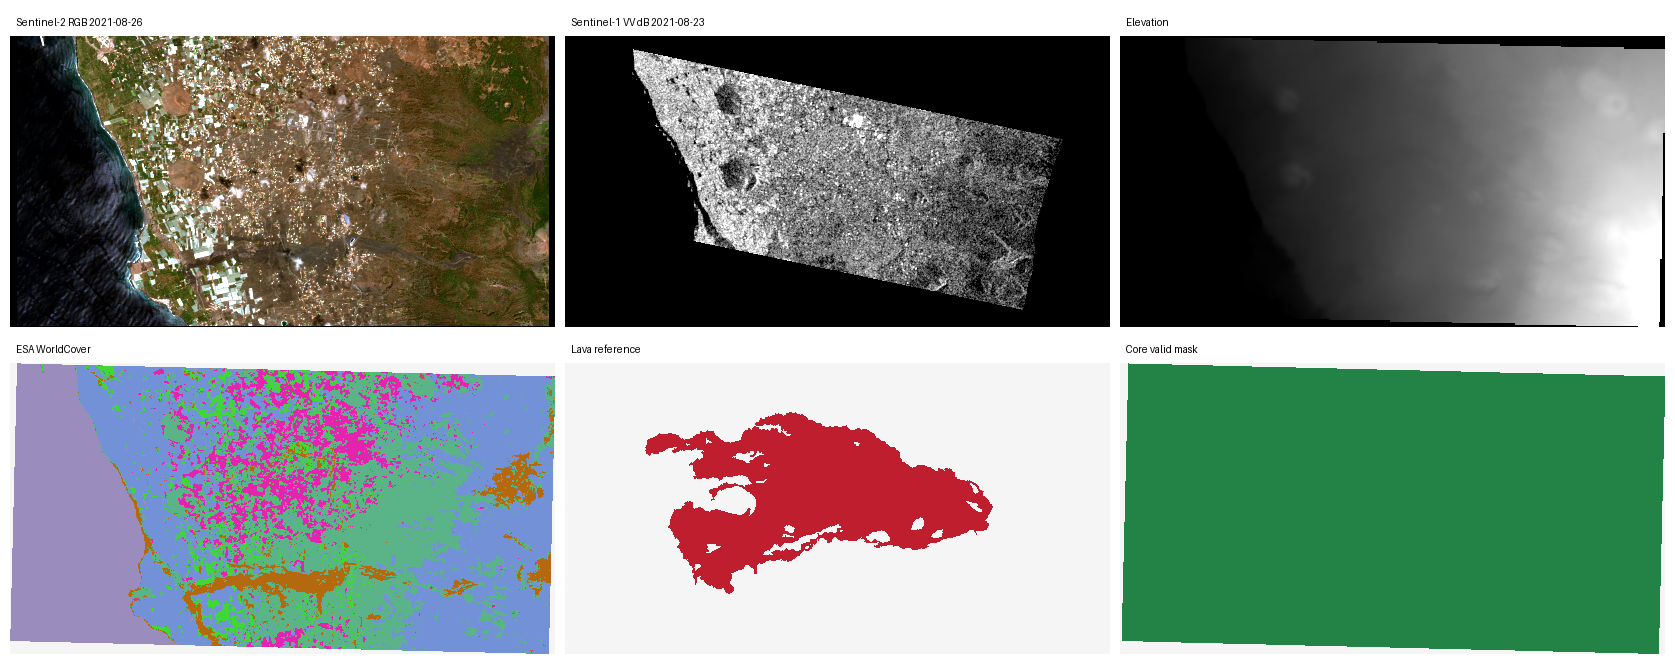

In [8]:
def read_band_by_name(src, metadata, band_name):
    row = metadata.loc[metadata["band_name"] == band_name]
    if row.empty:
        raise KeyError(f"Band not found: {band_name}")
    return src.read(int(row["band_index"].iloc[0]))

def stretch_rgb(rgb, valid=None, p_low=2, p_high=98):
    out = np.zeros_like(rgb, dtype="float32")
    for i in range(rgb.shape[0]):
        band = rgb[i]
        mask = np.isfinite(band) if valid is None else (valid & np.isfinite(band))
        if mask.any():
            lo, hi = np.nanpercentile(band[mask], [p_low, p_high])
            out[i] = np.clip((band - lo) / max(hi - lo, 1e-6), 0, 1)
    return np.moveaxis(out, 0, -1)

def stretch_gray(arr, p_low=2, p_high=98):
    arr = np.asarray(arr, dtype="float32")
    out = np.zeros(arr.shape, dtype="float32")
    mask = np.isfinite(arr)
    if mask.any():
        lo, hi = np.nanpercentile(arr[mask], [p_low, p_high])
        out = np.clip((arr - lo) / max(hi - lo, 1e-6), 0, 1)
        out[~mask] = 0
    return (out * 255).astype("uint8")

def rgb_to_uint8(rgb_arr):
    clean = np.nan_to_num(rgb_arr, nan=0.0, posinf=1.0, neginf=0.0)
    return (np.clip(clean, 0, 1) * 255).astype("uint8")

def gray_to_rgb(arr):
    gray = stretch_gray(arr)
    return np.dstack([gray, gray, gray])

def mask_to_rgb(mask, color):
    out = np.full((*mask.shape, 3), 245, dtype="uint8")
    valid = np.asarray(mask) > 0.5
    out[valid] = np.array(color, dtype="uint8")
    return out

def category_to_rgb(arr):
    codes = np.asarray(arr)
    out = np.full((*codes.shape, 3), 245, dtype="uint8")
    finite_codes = sorted(int(v) for v in np.unique(codes[np.isfinite(codes)]) if v > 0)
    for code in finite_codes:
        color = np.array([(37 * code) % 255, (91 * code) % 255, (149 * code) % 255], dtype="uint8")
        out[codes == code] = color
    return out

def add_title(image_array, title):
    image = PILImage.fromarray(image_array.astype("uint8"), mode="RGB")
    title_height = 26
    panel = PILImage.new("RGB", (image.width, image.height + title_height), "white")
    draw = ImageDraw.Draw(panel)
    draw.text((6, 6), title, fill="black")
    panel.paste(image, (0, title_height))
    return panel

def make_qc_mosaic(panels, columns=3, padding=10):
    width = max(panel.width for panel in panels)
    height = max(panel.height for panel in panels)
    rows = int(np.ceil(len(panels) / columns))
    canvas = PILImage.new(
        "RGB",
        (columns * width + (columns + 1) * padding, rows * height + (rows + 1) * padding),
        "white",
    )
    for i, panel in enumerate(panels):
        row = i // columns
        col = i % columns
        x = padding + col * (width + padding)
        y = padding + row * (height + padding)
        canvas.paste(panel, (x, y))
    buffer = BytesIO()
    canvas.save(buffer, format="PNG")
    return buffer.getvalue()

if VALIDATION_RASTER.exists() and VALIDATION_METADATA.exists():
    metadata = pd.read_csv(VALIDATION_METADATA)
    with rasterio.open(VALIDATION_RASTER) as src:
        red = read_band_by_name(src, metadata, "S2_20210826_B4")
        green = read_band_by_name(src, metadata, "S2_20210826_B3")
        blue = read_band_by_name(src, metadata, "S2_20210826_B2")
        rgb = stretch_rgb(np.stack([red, green, blue]), np.isfinite(red) & np.isfinite(green) & np.isfinite(blue))
        vv = read_band_by_name(src, metadata, "S1_20210823_VV_db")
        elevation = read_band_by_name(src, metadata, "elevation")
        land_cover = read_band_by_name(src, metadata, "land_cover")
        lava_reference = read_band_by_name(src, metadata, "lava_reference")
        core_valid_mask = read_band_by_name(src, metadata, "core_valid_mask")

    preview_step = 2
    preview = (slice(None, None, preview_step), slice(None, None, preview_step))
    panels = [
        add_title(rgb_to_uint8(rgb[preview[0], preview[1], :]), "Sentinel-2 RGB 2021-08-26"),
        add_title(gray_to_rgb(vv[preview]), "Sentinel-1 VV dB 2021-08-23"),
        add_title(gray_to_rgb(elevation[preview]), "Elevation"),
        add_title(category_to_rgb(land_cover[preview]), "ESA WorldCover"),
        add_title(mask_to_rgb(lava_reference[preview], (190, 30, 45)), "Lava reference"),
        add_title(mask_to_rgb(core_valid_mask[preview], (35, 130, 70)), "Core valid mask"),
    ]
    qc_png = make_qc_mosaic(panels)
    display(IPyImage(data=qc_png))
    if WRITE_QC_OUTPUTS:
        safe_write_png(qc_png, ALIGNMENT_PREVIEW_PATH)
else:
    print(f"Not checked: {VALIDATION_LABEL} GeoTIFF or metadata CSV is unavailable.")


## Generated Outputs and Downstream Analysis

With `BUILD_CANDIDATE_OUTPUTS = False`, this notebook does not create or overwrite raster or metadata build outputs. Existing canonical outputs are validated read-only:

- `data/processed/unified/LaPalma_unified_datastack_EPSG32628_10m.tif`
- `data/metadata/LaPalma_unified_datastack_band_metadata.csv`
- `data/metadata/README_datastack.md`

When `BUILD_CANDIDATE_OUTPUTS = True`, optional rebuild products are written only to:

- `data/processed/unified/LaPalma_unified_datastack_EPSG32628_10m_candidate.tif`
- `data/metadata/LaPalma_unified_datastack_band_metadata_candidate.csv`

Candidate files are not promoted automatically. A candidate must be validated before any manual replacement of canonical files.

With `WRITE_QC_OUTPUTS = False`, the validation table and visual alignment check are displayed in the notebook only. Optional QC exports can be enabled explicitly and are protected from silent overwrite:

- `outputs/tables/datastack_validation_summary.csv`
- `outputs/figures/datastack_alignment_preview.png`

Local input placement is documented in `data/README.md`, while upstream acquisition and preprocessing provenance is documented in `docs/DATA_PIPELINE.md`.

Use `notebooks/01_lapalma_analysis_final.ipynb` for downstream optical/SAR diagnostics, Random Forest spectral-evidence classification, constrained affected-surface timing reconstruction, and land-cover, terrain, and infrastructure exposure assessment.
